In [1]:
import tables
from ctapipe.visualization import CameraDisplay
from ctapipe.coordinates import EngineeringCameraFrame
from ctapipe_io_lst import LSTEventSource
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy.stats import chi2

# CAMERA GEOMETRY------ 
sa = LSTEventSource.create_subarray(tel_id=1)
focal_length = sa.tel[1].optics.equivalent_focal_length
camera_geom = sa.tel[1].camera.geometry

# ROBUST FIT FUNCTION 
def robust_fitt(x, y, z_thresh=3.5):
    X = x.astype(float).reshape(-1, 1)
    Xc = sm.add_constant(X)
    fit = np.zeros_like(y, dtype=float)
    slope = np.zeros(y.shape[1])
    u_slope = np.zeros(y.shape[1])
    intercept = np.zeros(y.shape[1])
    u_intercept = np.zeros(y.shape[1])
    R2 = np.zeros(y.shape[1]) 
    good_points = []
    valid = []  # True/False per column
    good_masks = [] #to get the positions of the good points

    for p in range(y.shape[1]):
        yp = y[:, p]
        model = sm.OLS(yp, Xc).fit()
        residual = np.abs(yp - model.predict(Xc))
        mad = np.median(np.abs(residual - np.median(residual)))
        mad = max(mad, 1e-12)  # avoid division by zero
        modified_z = 0.6745 * residual / mad
        good = modified_z <= z_thresh
        good_masks.append(good)
        
        if good.sum() >= 0.6*len(x):  # if we take only 2 points, the line of the fit will cross them exactly, giving sigma=0 (both residuals=0)
            good_points.append((x[good], yp[good]))
            
            model = sm.OLS(yp[good], Xc[good]).fit()
            fit[:, p] = model.predict(Xc)
            intercept[p] = model.params[0]
            slope[p] = model.params[1]
            u_intercept[p] = model.bse[0]
            u_slope[p] = model.bse[1]
            R2[p] = (model.rsquared) 
            valid.append(True)
            
        else:
            good_points.append((None, None))
            fit[:, p] = np.nan
            intercept[p] = np.nan
            slope[p] = np.nan
            u_intercept[p] = np.nan
            u_slope[p] = np.nan
            R2[p] = np.nan
            valid.append(False)
        

    return {"fit": fit, "slope": slope, "u_slope": u_slope,
            "intercept": intercept, "u_intercept": u_intercept,
            "good_points": good_points, "good_mask": good_masks, "valid": valid, "R2": R2}

# WEIGHTED PCA FUNCTION--------------------------------------
def wpca(m, w):
  """
  m : (N, 2)
  w :  (N,)
  
  centroid : (2,)  [x_c, y_c]
  direction_vector : (2,) [u_x, u_y] (unitario)
  """
  w = w / np.sum(w)

  centroid = np.average(m, weights=w, axis=0)

  m_centered = m - centroid # centering data
  cov_matrix = (m_centered.T * w) @ m_centered # covariance matrix

  eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
  main_axis_index = np.argmax(eigenvalues)
  direction_vector = eigenvectors[:, main_axis_index]

  return centroid, direction_vector

# RUN ID'S TO LOOK
run_id_list = [20767, 20757, 20721]

for run_id in run_id_list:
# READING RESULTS -------------------------------------------------------------------------------------------------------------------------------
    print("\n" + "="*80)
    print(f"Run {run_id}")
    print("="*80)
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/1500_checks_h5/checks_Run{run_id}.h5".format(run_id= run_id))
    #b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/try_checks_h5/checks_Run{run_id}.h5".format(run_id= run_id))
    for filt in ["filter1", "filter2", "filter2a", "filter2b", "filter2c"]:
    
        table = getattr(b.root.perfilter, filt)
        
        print(f"\n{'='*60}")
        print(f"{filt.upper()}")
        print(f"{'='*60}")
        
        if len(table) == 0:
            print("No checks found.")
            continue
    
        sigma_cutoff = table[0]["sigma_cutoff"]     
        print(f"Sigma cutoff = {sigma_cutoff}")
        
        fit = table[0]["fit_parameters"]
        slope, u_slope, intercept, u_intercept = fit
        
        print("Fit parameters:")
        print(f"  slope     = {slope:.6f} ± {u_slope:.6f}")
        print(f"  intercept = {intercept:.6f} ± {u_intercept:.6f}")
        
        print("\nChecks:")
        print(f"{'Subrun':>8} {'z-score':>10}")
        print("-" * 20)
        
        for row in table:
            print(f"{row['check_index']:>8} {row['z_score']:>10.3f}")
    
        
    print("\nCoincident checks:")
    
    table = b.root.general.coincident_checks
    
    if len(table) == 0:
        print("  None")
    else:
        for row in table:
            print(f"  {row['check_index']}")


Run 20767

FILTER1
Sigma cutoff = 20.0
Fit parameters:
  slope     = -2.932000 ± 0.218212
  intercept = 6501.075817 ± 8.491834

Checks:
  Subrun    z-score
--------------------
      14     20.302
      15     39.205
      16     24.942
      44   2528.976

FILTER2
Sigma cutoff = 10.0
Fit parameters:
  slope     = -0.000016 ± 0.000014
  intercept = 0.006158 ± 0.000538

Checks:
  Subrun    z-score
--------------------
      13     13.254
      14     16.072
      15     12.515
      16     16.990

FILTER2A
Sigma cutoff = 6.0
Fit parameters:
  slope     = -0.000005 ± 0.000017
  intercept = 0.007233 ± 0.000676

Checks:
  Subrun    z-score
--------------------
      13     19.259
      14     14.162
      15     12.578
      16     22.135

FILTER2B
No checks found.

FILTER2C
No checks found.

Coincident checks:
  13
  14
  15
  16

Run 20757

FILTER1
Sigma cutoff = 20.0
Fit parameters:
  slope     = -0.779939 ± 0.078994
  intercept = 7211.573051 ± 7.749102

Checks:
  Subrun    z-score
---

/data/cta/software/conda/miniforge3/envs/lstchain-v0.12.3/lib/python3.11/site-packages/ctapipe/core/provenance.py:280: MissingReferenceMetadata: Could not read reference metadata for input file: /data/cta/software/conda/miniforge3/envs/lstchain-v0.12.3/lib/python3.11/site-packages/ctapipe_io_lst/resources/oversampled_pulse_LST_8dynode_pix6_20200204.dat
  warnings.warn(


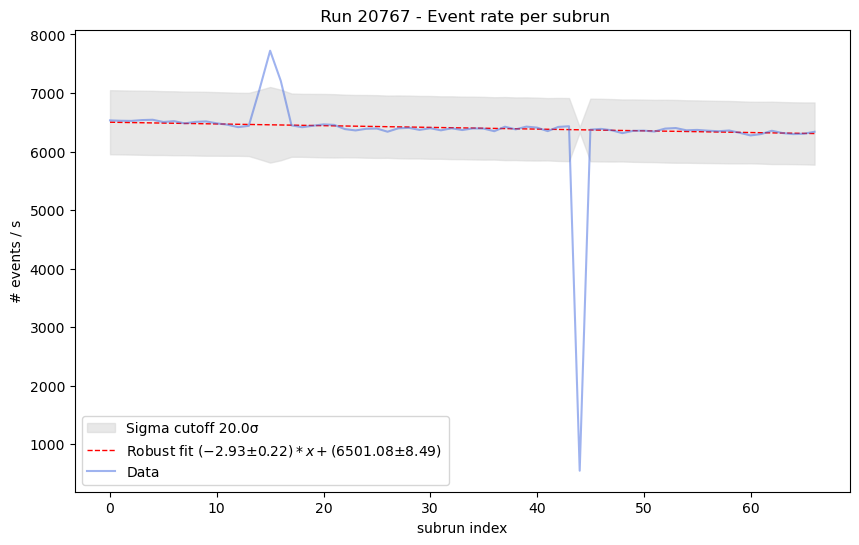

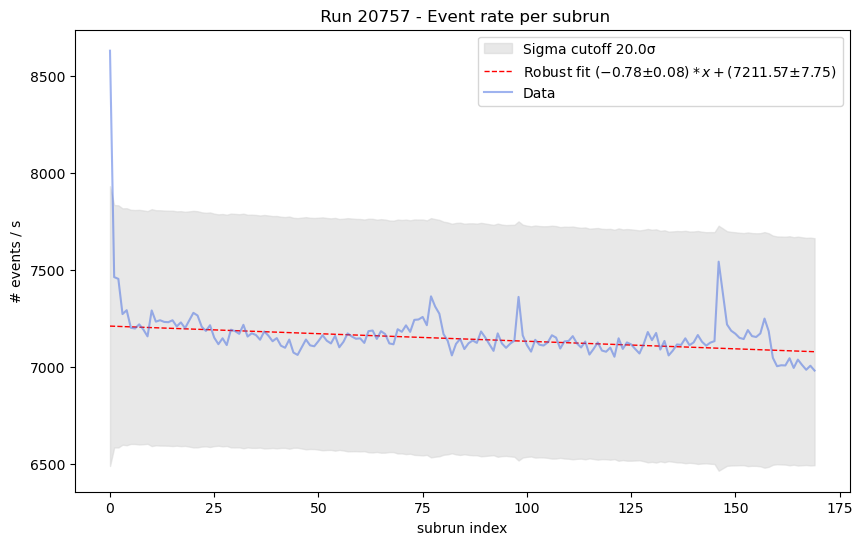

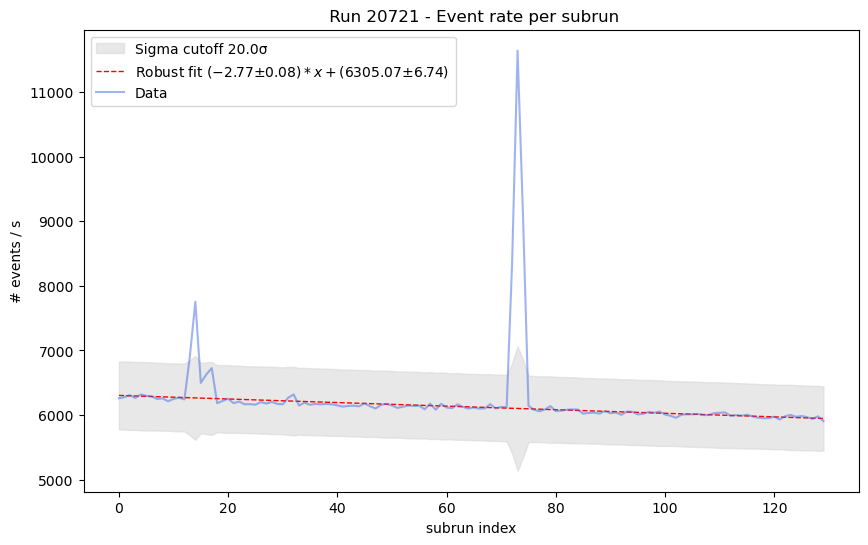

In [2]:
# FILTERS REVISION-------------------------------------------------------------------------------------------------------------------------------------------
# FILTER 1------------------------------------------------------------------------
#a = tables.open_file("/data/cta/users-ifae/summer_students/agl/datacheck_dl1_LST-1.Run24704.h5")
for run_id in run_id_list:
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/1500_checks_h5/checks_Run{run_id}.h5".format(run_id= run_id))
    a = tables.open_file(r"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5".format(run_id= run_id))
    
    subruns = a.root.dl1datacheck.cosmics.col('subrun_index')[:-1] #0,1,...,57 number of subruns in this run
    n_subruns = len(subruns)
    time = a.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]
    
    num_events = a.root.dl1datacheck.cosmics.col('num_events')[:-1] # events in each subrun
    event_rate = num_events / time
    event_rate_sigma = np.sqrt(np.maximum(num_events, 1.0)) / time  
    
    # ROBUST FIT
    
    #event_rate_robfit = robust_fitt(subruns, event_rate.reshape(-1, 1))
    #event_rate_fit = event_rate_robfit["fit"].flatten()
    x_fit = np.linspace(min(subruns), max(subruns), n_subruns)
    fit_slope = b.root.perfilter.filter1.col('fit_parameters')[0][0]
    fit_u_slope = b.root.perfilter.filter1.col('fit_parameters')[0][1]
    fit_intercept =  b.root.perfilter.filter1.col('fit_parameters')[0][2]
    fit_u_intercept =  b.root.perfilter.filter1.col('fit_parameters')[0][3]
    event_rate_fit = fit_slope * x_fit + fit_intercept
    
    sigma_cutoff_1 = b.root.perfilter.filter1.col("sigma_cutoff")[0]
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(
        subruns,
        event_rate_fit - sigma_cutoff_1 * event_rate_sigma,
        event_rate_fit + sigma_cutoff_1* event_rate_sigma,
        color='lightgray', alpha= 0.5, label=f'Sigma cutoff {sigma_cutoff_1}σ'
    )
    plt.plot(subruns, event_rate_fit, label=f'Robust fit $({fit_slope:.2f}±{fit_u_slope:.2f}) * x + ({fit_intercept:.2f}±{fit_u_intercept:.2f})$ ', color='red', linestyle='--', linewidth=1)
    plt.plot(subruns, event_rate, color='royalblue', alpha=0.5, label='Data')
    plt.title(f' Run {run_id} - Event rate per subrun')
    plt.ylabel('# events / s')
    plt.xlabel('subrun index')
    plt.legend()
    plt.show()
    a.close()
    b.close()



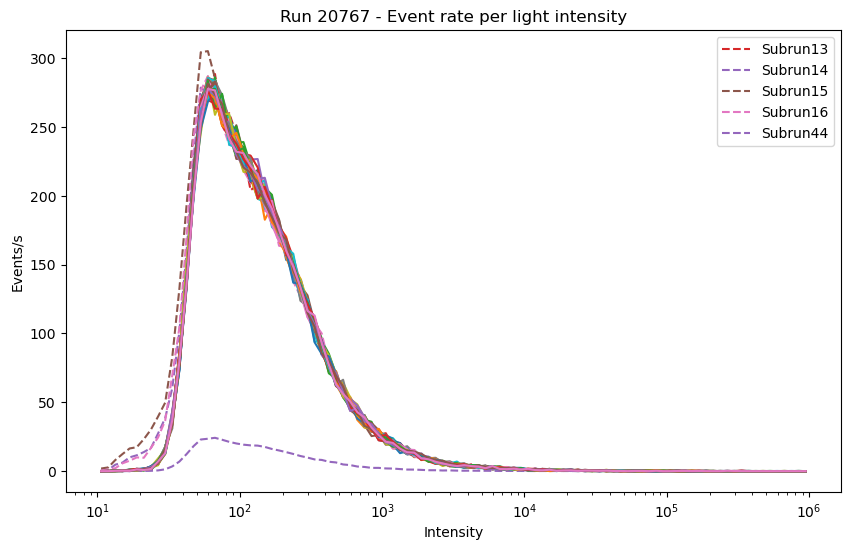

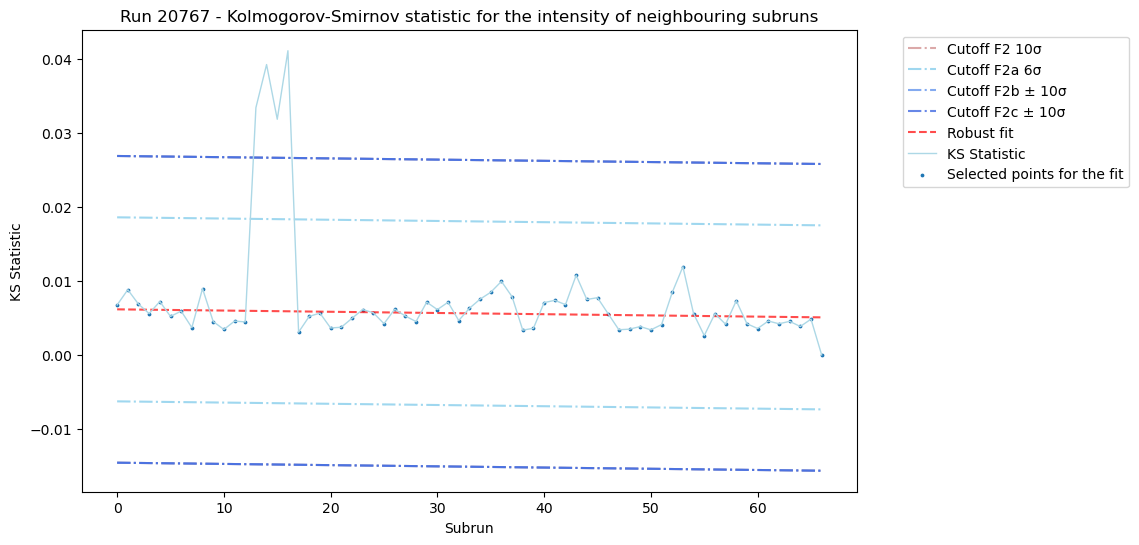

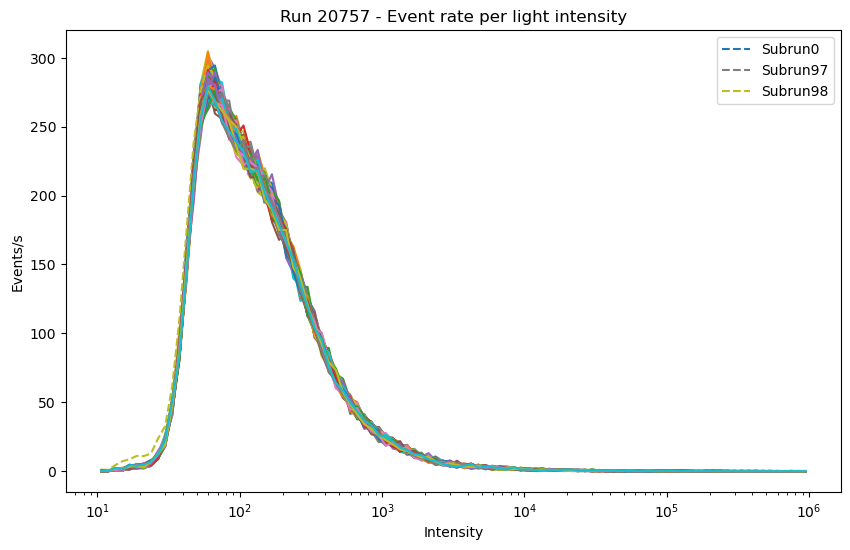

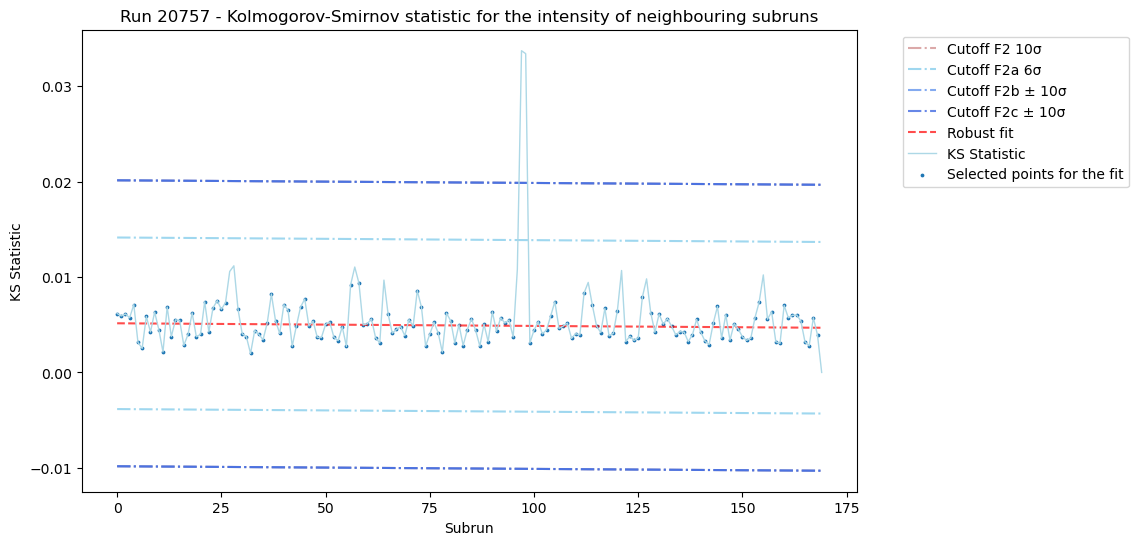

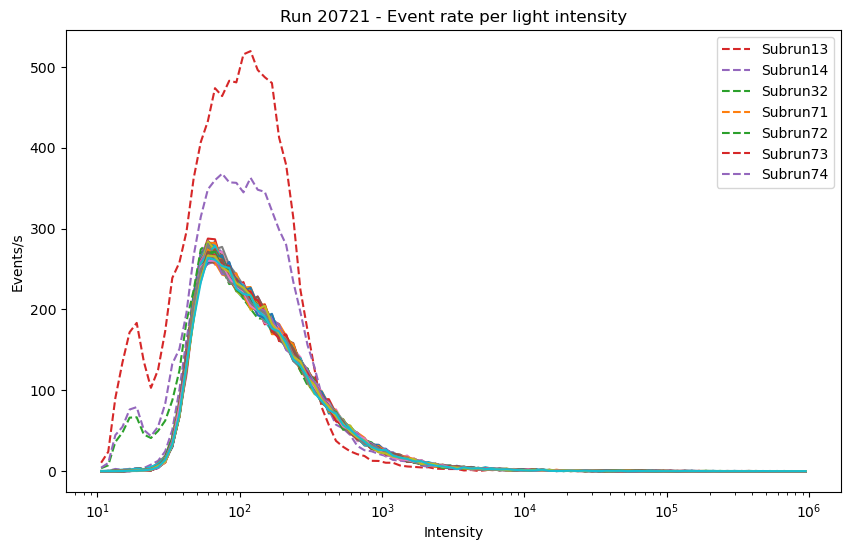

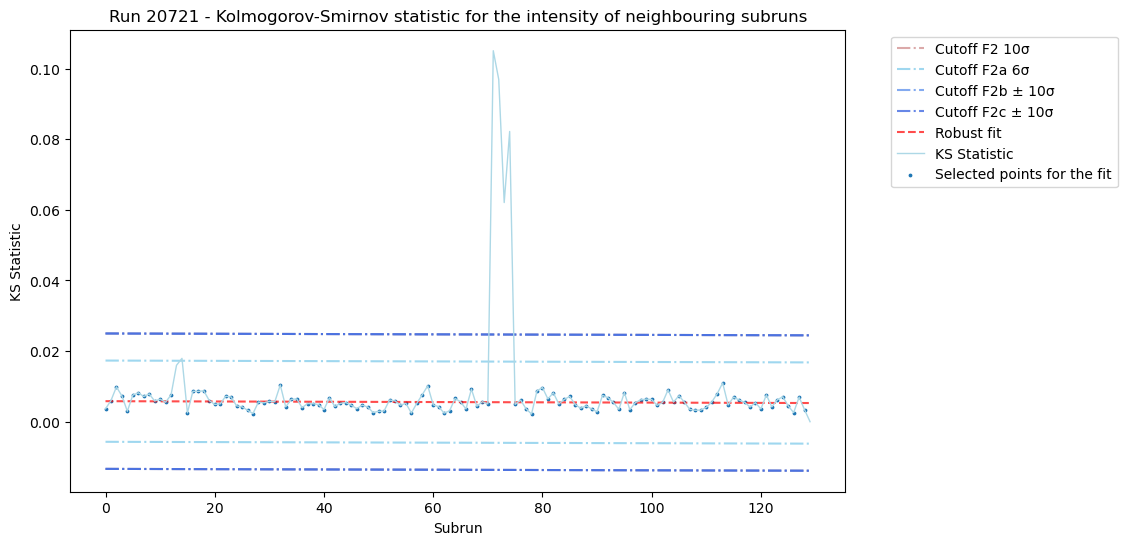

In [10]:
# FILTER 2: EVENT RATE VS INTENSITY------------------------------------------------------
for run_id in run_id_list:
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/1500_checks_h5/checks_Run{run_id}.h5".format(run_id= run_id))
    a = tables.open_file(r"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5".format(run_id= run_id))

    subruns =  a.root.dl1datacheck.cosmics.col('subrun_index')[:-1]
    time = a.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]
    hist_intensity = a.root.dl1datacheck.cosmics.col('hist_intensity')[:-1]
    intensity_bins = a.root.dl1datacheck.histogram_binning.col('hist_intensity')[0]
    intensity = 0.5*(intensity_bins[1:]+intensity_bins[:-1])  
    
    cdf = np.cumsum(hist_intensity / np.maximum(hist_intensity.sum(axis=1, keepdims=True),1), axis=1)   #we need to normalize the histogram. 1 cdf per subrun
    D = np.zeros(len(subruns)) 
    
    for s in range(0, len(subruns)-1):
        D[s] = np.max(np.abs(cdf[s] - cdf[s+1])) #we compare the CDF in each subrun 's' with its neighbouring one 's+1'
    
    #Do a robust fit of D to select the good points
    D_robust_fit = robust_fitt(subruns, D.reshape(-1, 1))
    sigma_cutoff_2 = 10
    sigma_cutoff_2a = 6
    sigma_cutoff_2b = 10
    sigma_cutoff_2c = 10
    D_good = D_robust_fit["good_points"][0][1]  # y-selected values for this column
    D_fit = D_robust_fit["fit"].flatten()       
    
    good_mask_2 = D_robust_fit["good_mask"][0]               
    D_fit_good = D_fit[good_mask_2]                # take the fit only at the 'good points' to calculate the sigmas
    
    sigma_2 = np.std(D_good - D_fit_good) # calculate the sigma for those good points so that it is not biased 
    
    # This is not a Poisson process therefore we cannot treat it as such
    
    # PLOT INTENSITIES
    checks = b.root.general.cosmics.col("subrun_index")
    plt.figure(figsize=(10, 6))   
    
    for s in range(hist_intensity.shape[0]):  
        event_rate_i = hist_intensity[s] / time[s]
        if s in checks:
            plt.plot(intensity, event_rate_i, linestyle='--', label=f'Subrun{s}')
        else:
             plt.plot(intensity, event_rate_i)
    
    plt.legend()
    plt.title(f'Run {run_id} - Event rate per light intensity')
    plt.xlabel('Intensity')
    plt.ylabel('Events/s')
    plt.xscale('log')
    plt.show()
    
    # PLOT KOLMOGOROV
    plt.figure(figsize=(10, 6))
    plt.plot(subruns, D_fit + sigma_cutoff_2 * sigma_2, color='brown', linestyle='-.', alpha= 0.4, label=f'Cutoff F2 {sigma_cutoff_2}σ')
    plt.plot(subruns, D_fit - sigma_cutoff_2 * sigma_2, color='brown', linestyle='-.', alpha= 0.4)
    plt.plot(subruns, D_fit + sigma_cutoff_2a * sigma_2, color='skyblue', linestyle='-.', alpha= 0.8, label=f'Cutoff F2a {sigma_cutoff_2a}σ')
    plt.plot(subruns, D_fit - sigma_cutoff_2a * sigma_2, color='skyblue', linestyle='-.', alpha= 0.8)
    plt.plot(subruns, D_fit + sigma_cutoff_2b * sigma_2, color='cornflowerblue', linestyle='-.', alpha= 0.8, label=f'Cutoff F2b ± {sigma_cutoff_2b}σ')
    plt.plot(subruns, D_fit - sigma_cutoff_2b * sigma_2, color='cornflowerblue', linestyle='-.', alpha= 0.8)
    plt.plot(subruns, D_fit + sigma_cutoff_2c * sigma_2, color='royalblue', linestyle='-.', alpha= 0.8, label=f'Cutoff F2c ± {sigma_cutoff_2c}σ')
    plt.plot(subruns, D_fit - sigma_cutoff_2c * sigma_2, color='royalblue', linestyle='-.', alpha= 0.8)
    
    
    plt.plot(subruns, D_fit, label='Robust fit', alpha=0.7, color='red', linestyle='--')
    plt.plot(subruns, D, linewidth=1, color='lightblue', label='KS Statistic')
    plt.scatter(D_robust_fit["good_points"][0][0], D_robust_fit["good_points"][0][1], label='Selected points for the fit', s=3)
    plt.xlabel('Subrun')
    plt.ylabel('KS Statistic')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f'Run {run_id} - Kolmogorov-Smirnov statistic for the intensity of neighbouring subruns')
    plt.show()

    a.close()
    b.close()



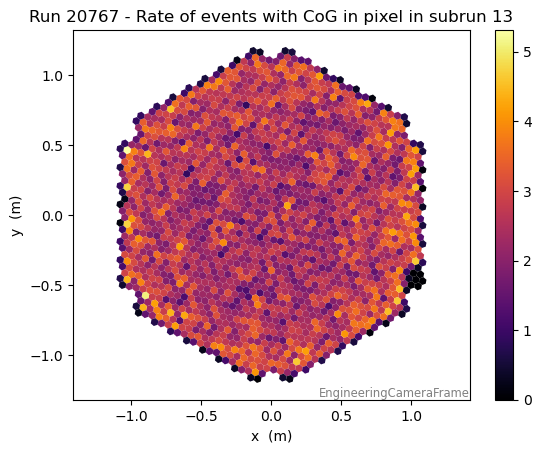

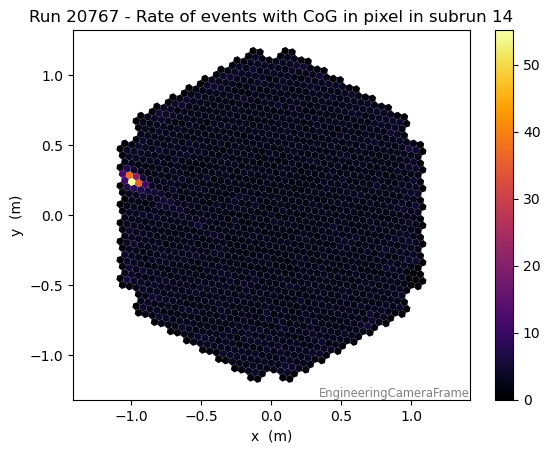

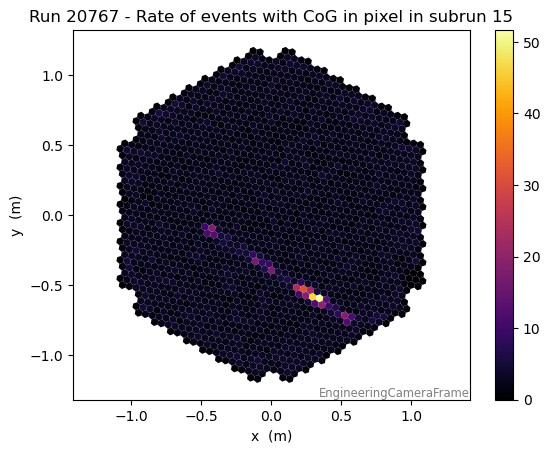

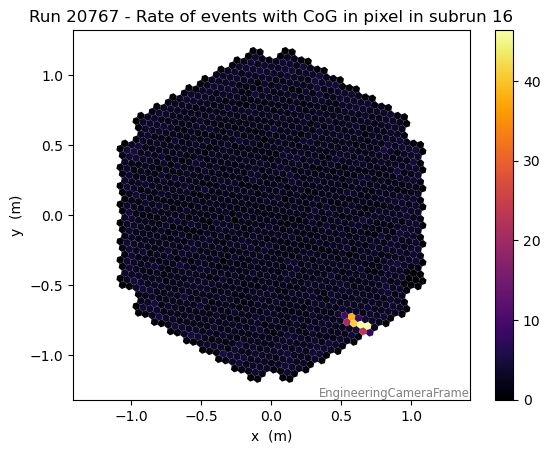

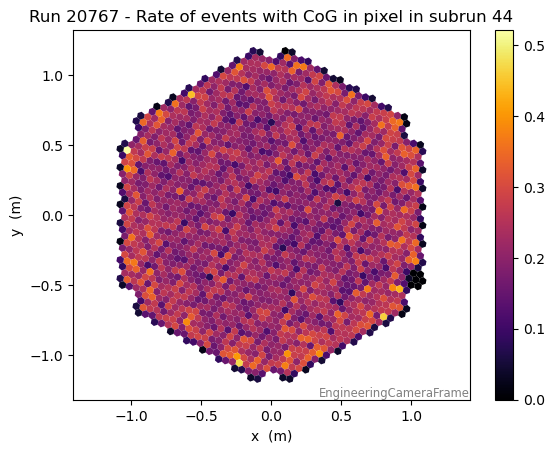

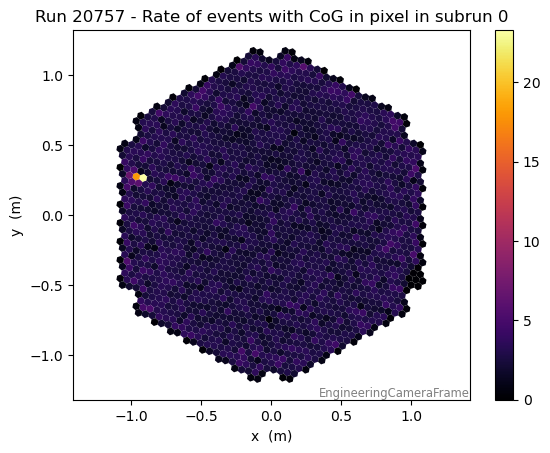

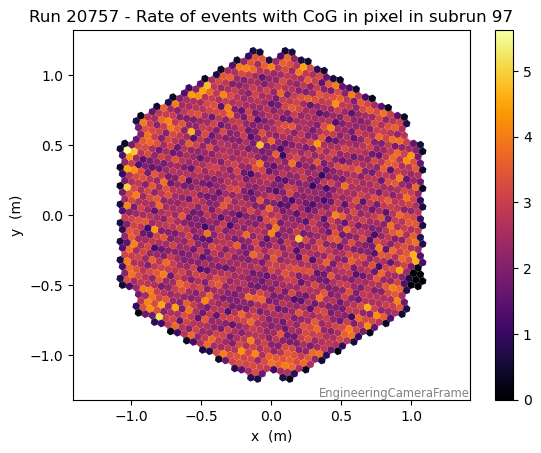

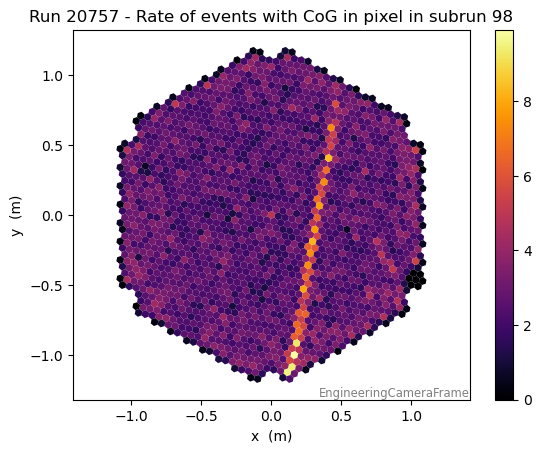

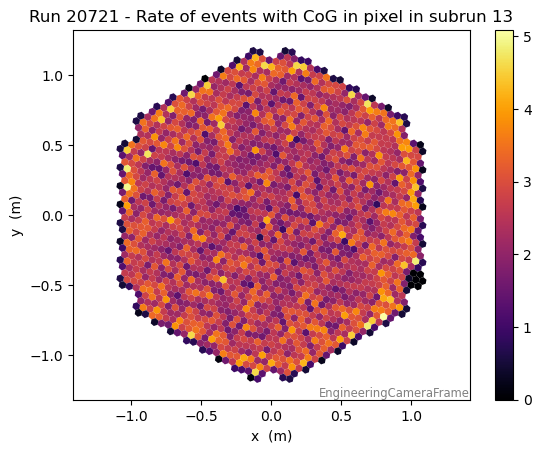

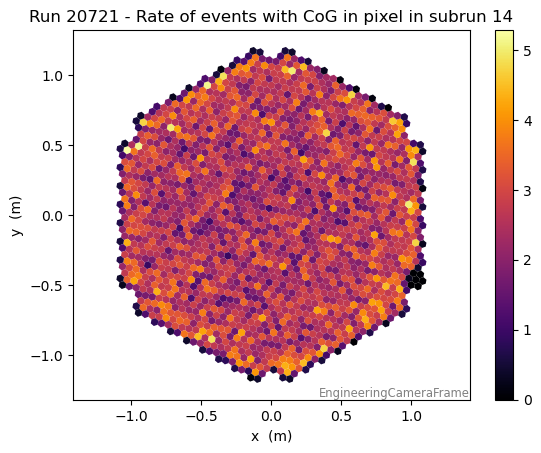

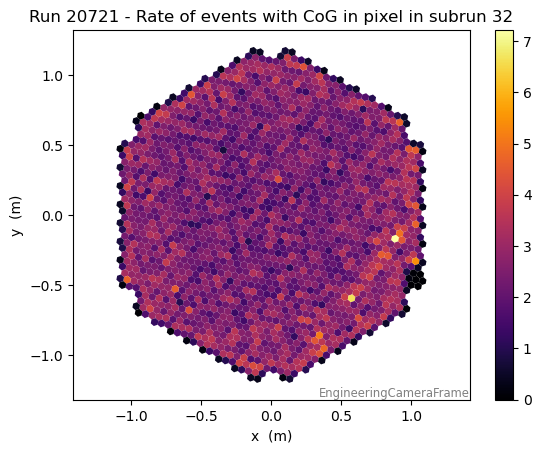

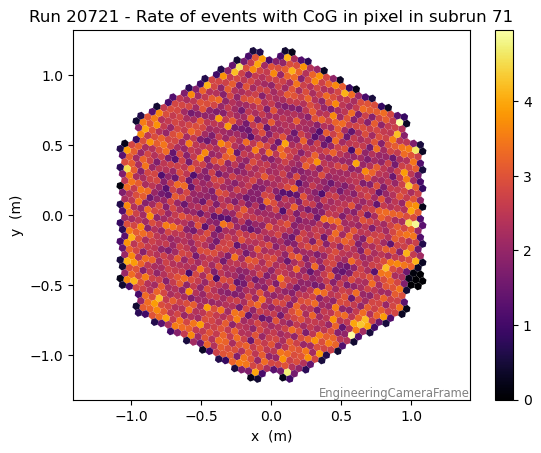

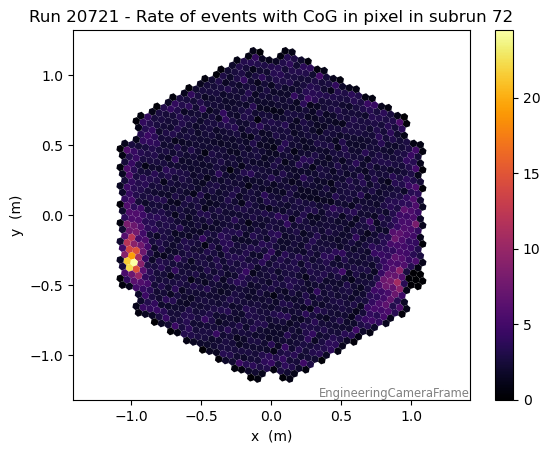

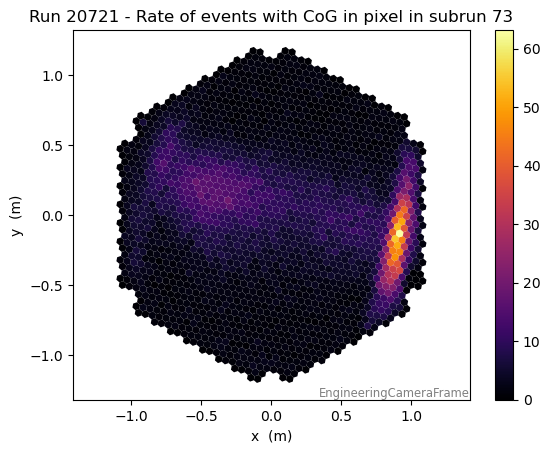

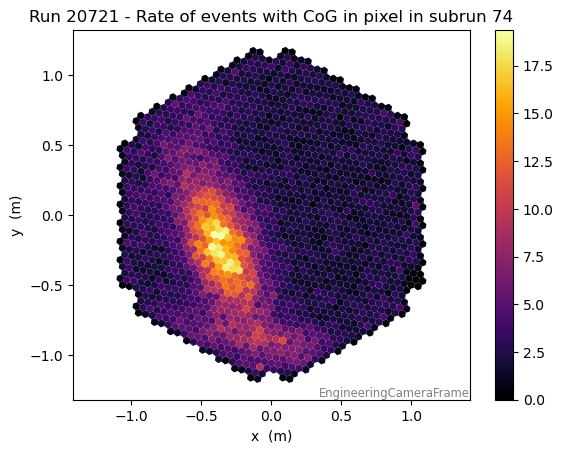

In [11]:
for run_id in run_id_list:
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/1500_checks_h5/checks_Run{run_id}.h5".format(run_id= run_id))
    a = tables.open_file(r"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5".format(run_id= run_id))
    time = a.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]
    
    checks = b.root.general.cosmics.col("subrun_index")
    for i in checks:
        camdisplay = CameraDisplay(camera_geom.transform_to(EngineeringCameraFrame()),
                              norm='lin', title=f'Run {run_id} - Rate of events with CoG in pixel in subrun {i}', 
                               image=(a.root.dl1datacheck.cosmics.col('cog_within_pixel')[:-1]/ time[:, None])[i,:])
        camdisplay.autoupdate = True
        camdisplay.add_colorbar()
        plt.show()
    b.close()
    a.close()


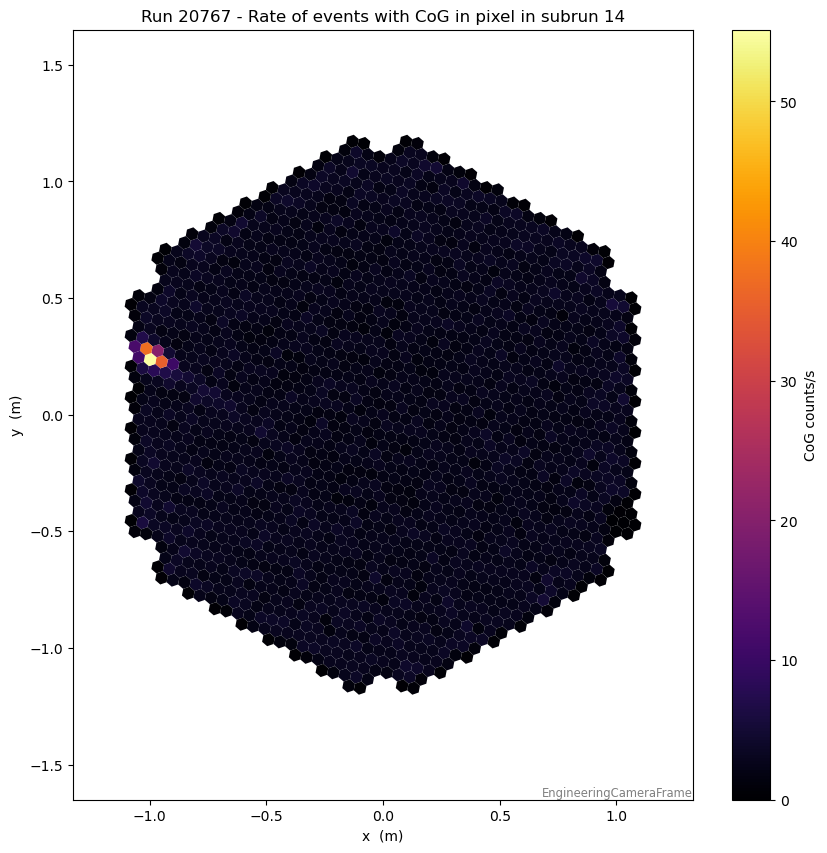

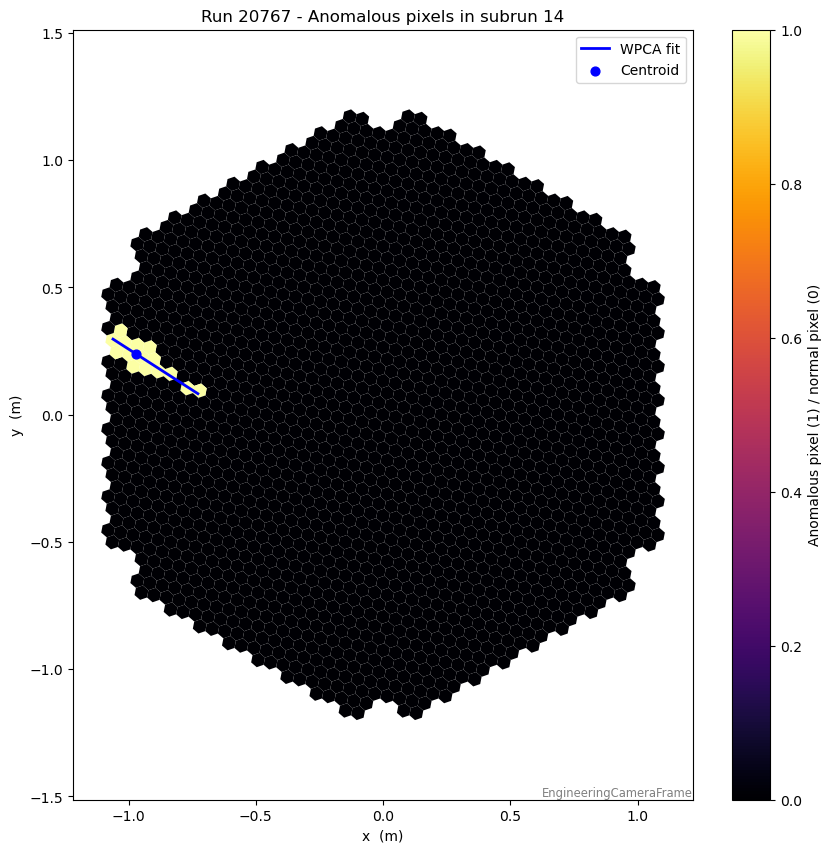

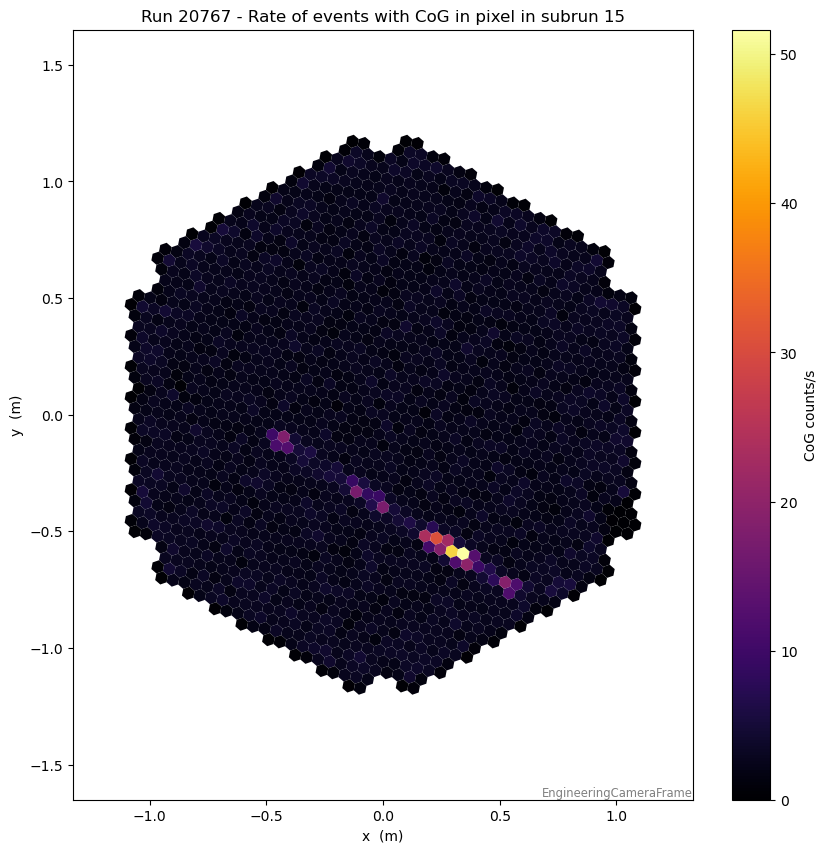

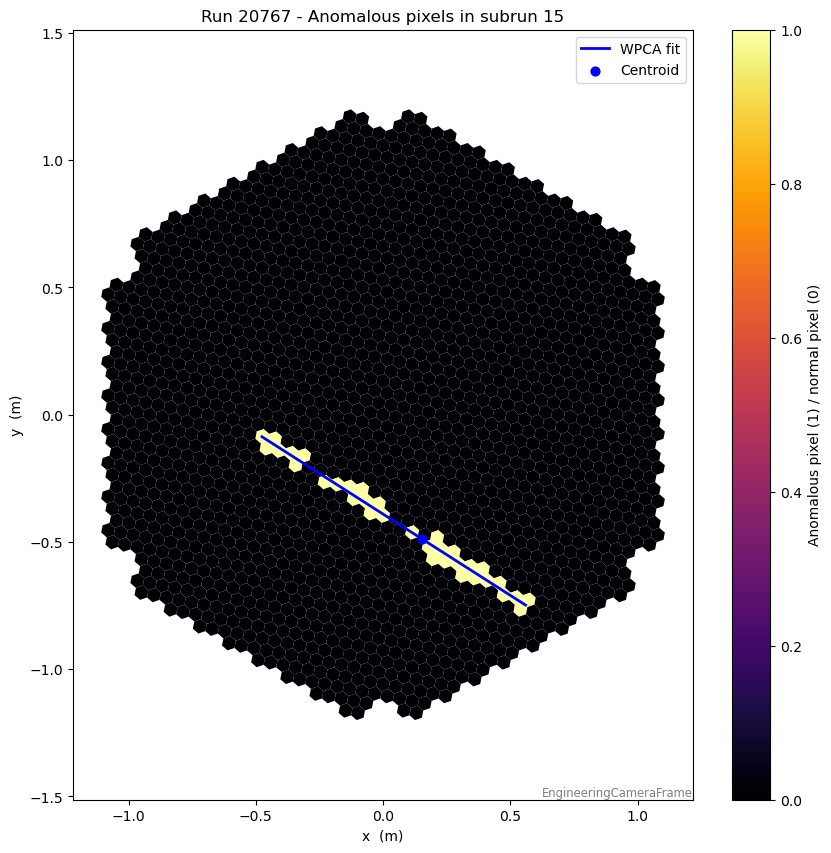

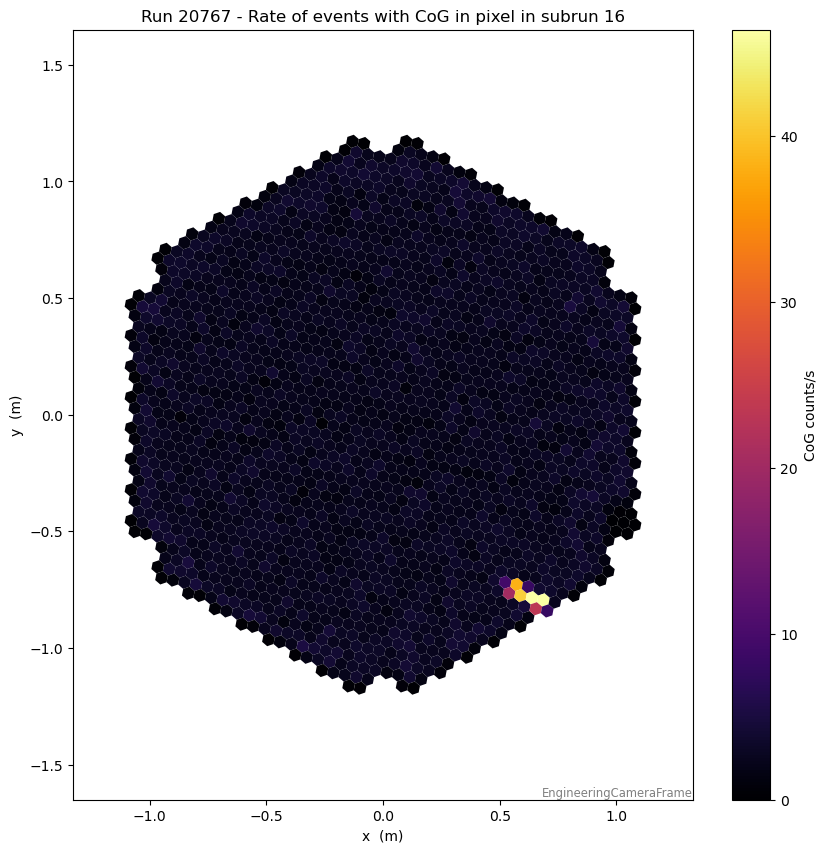

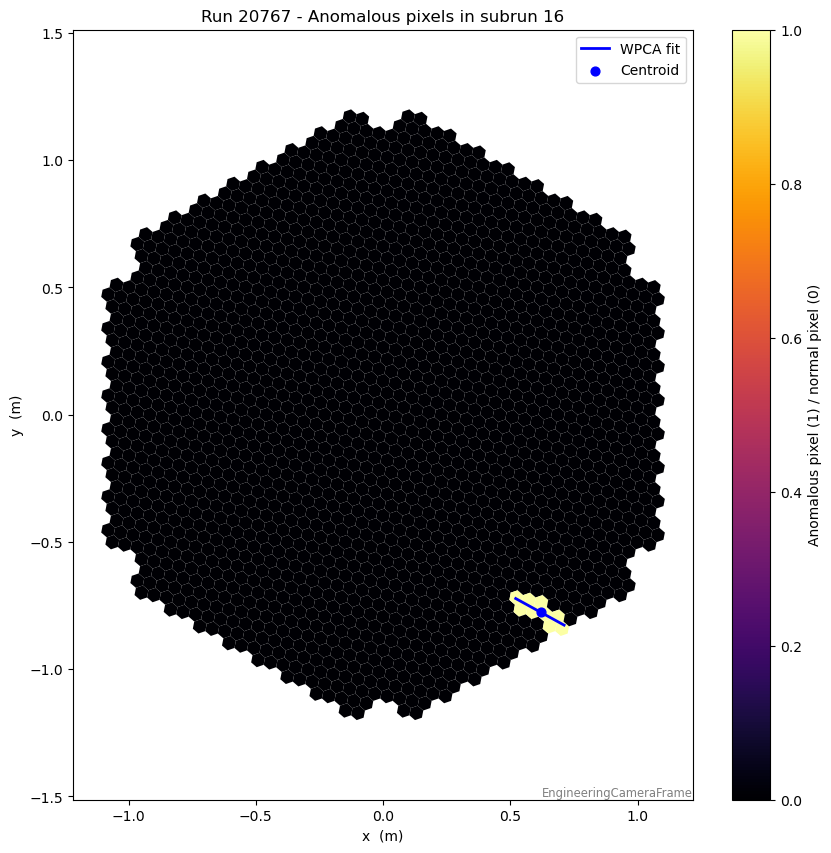

Run id:  [20767]
Chi2 data:  [np.float64(0.8520541375065122), np.float64(0.6121424490095982), np.float64(0.622264241279823)]


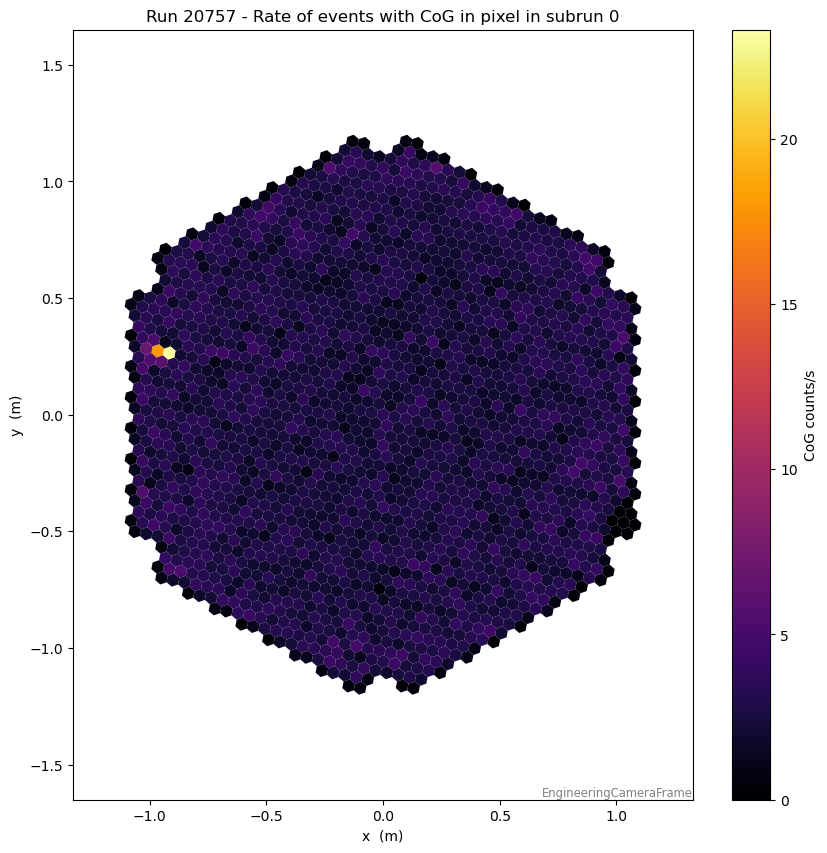

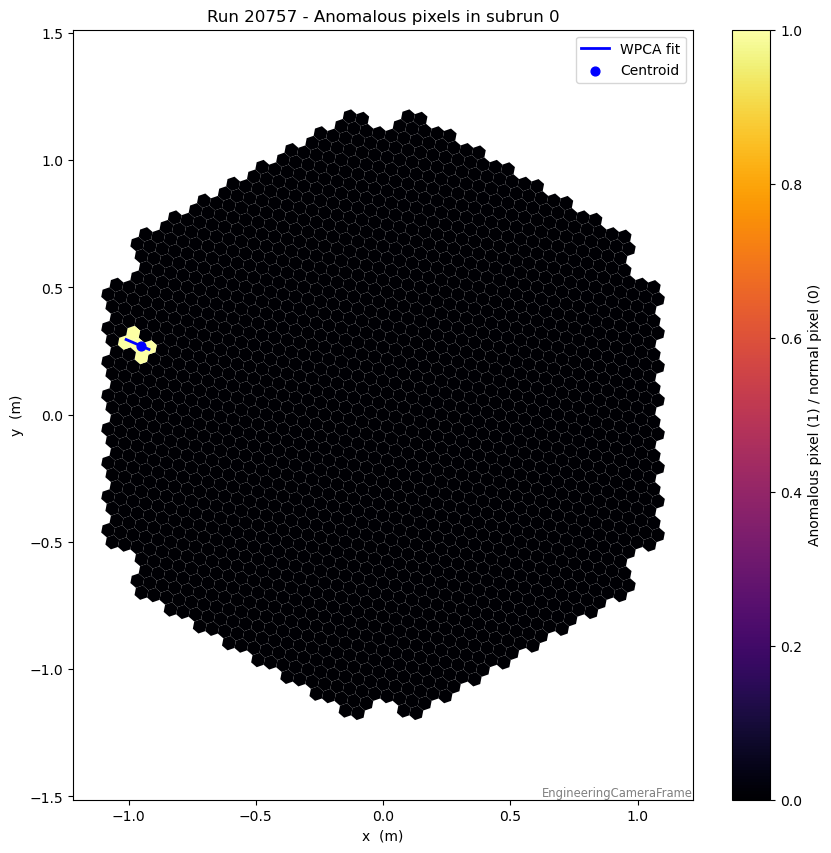

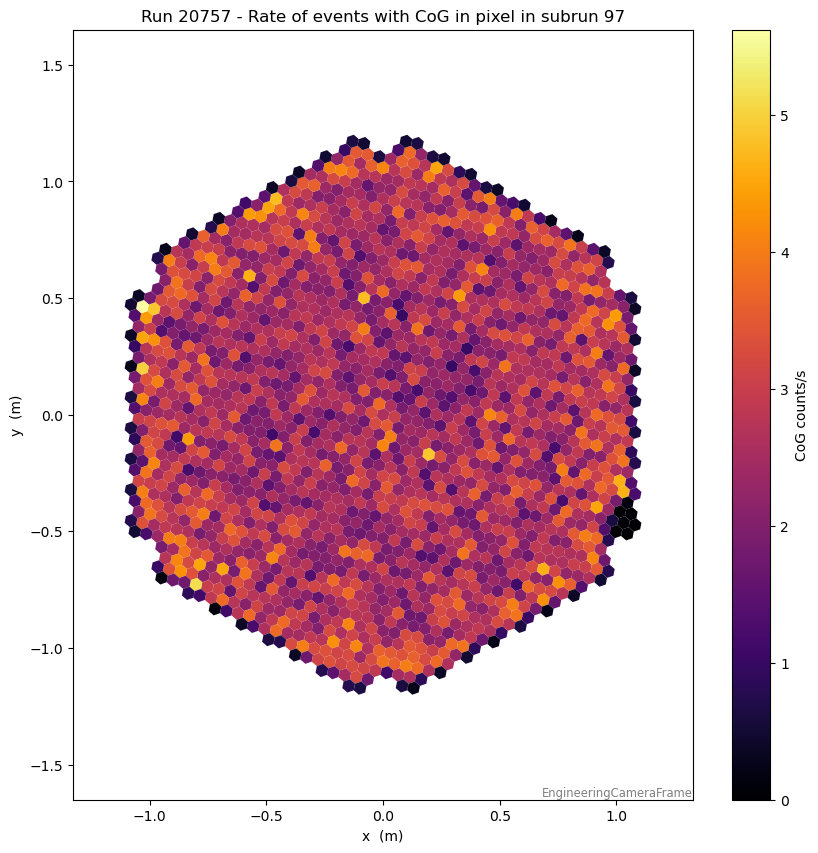

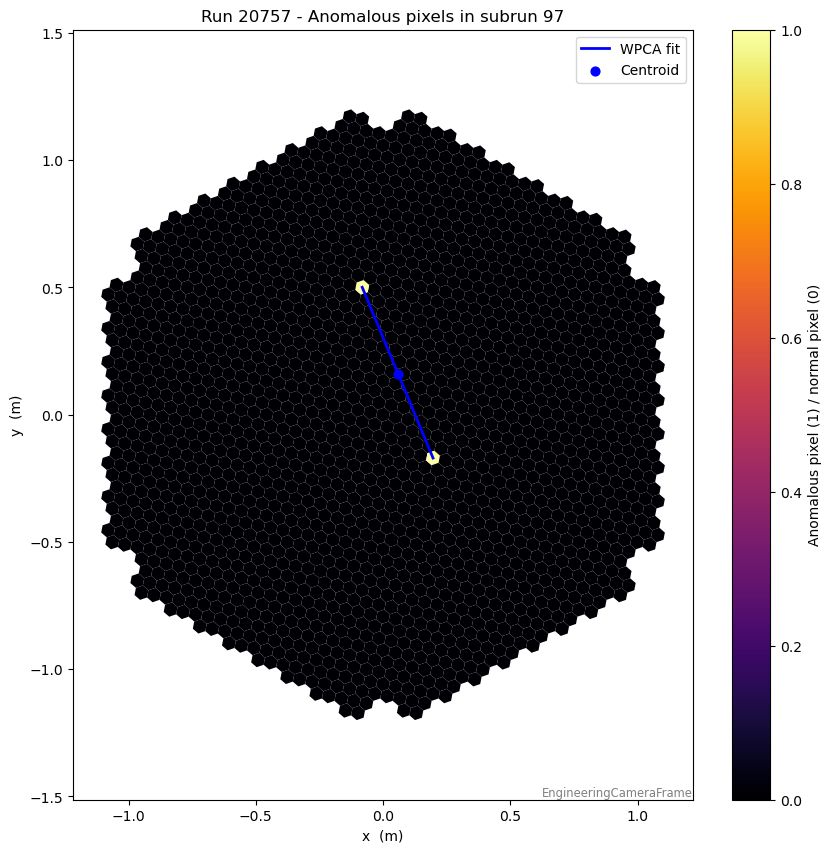

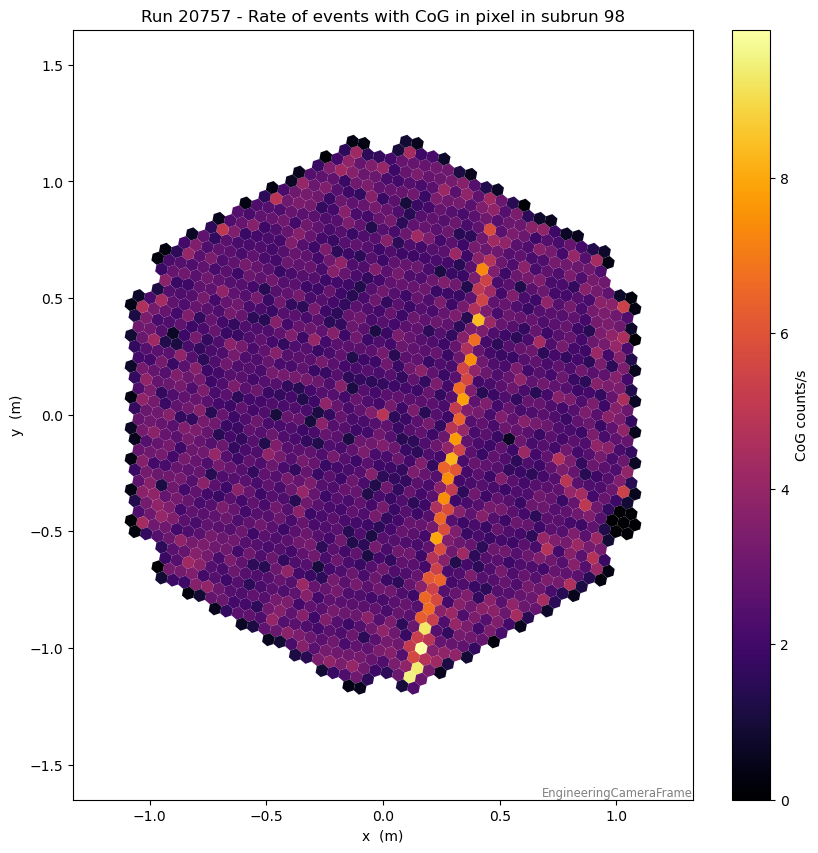

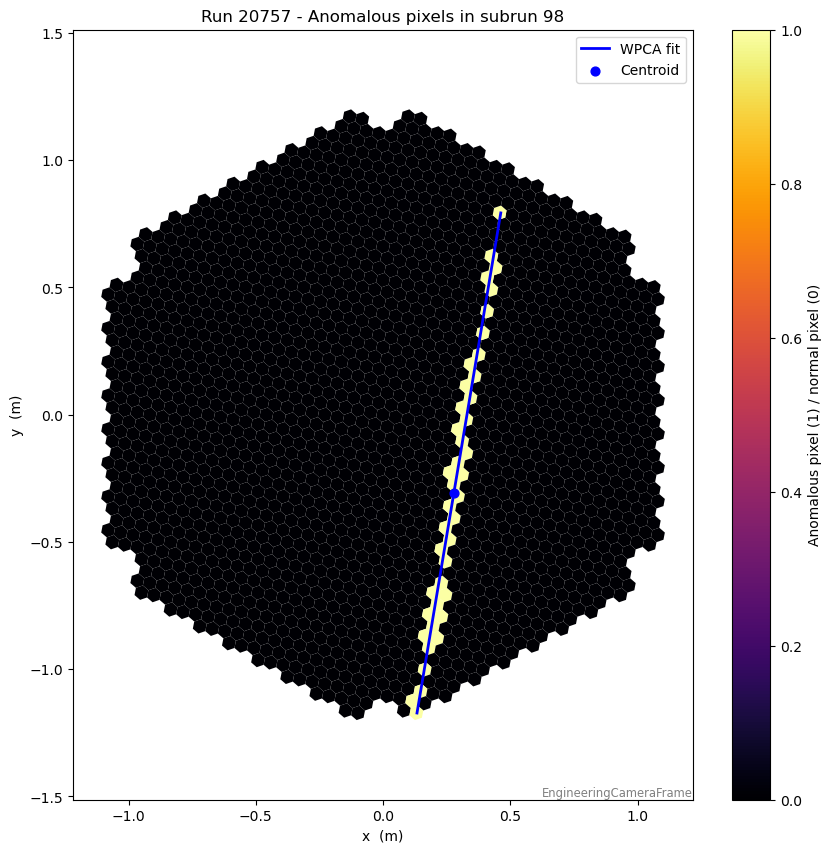

Run id:  [20757]
Chi2 data:  [np.float64(0.5163586250193567), np.float64(6.535266944286726e-31), np.float64(0.4121485170160065)]


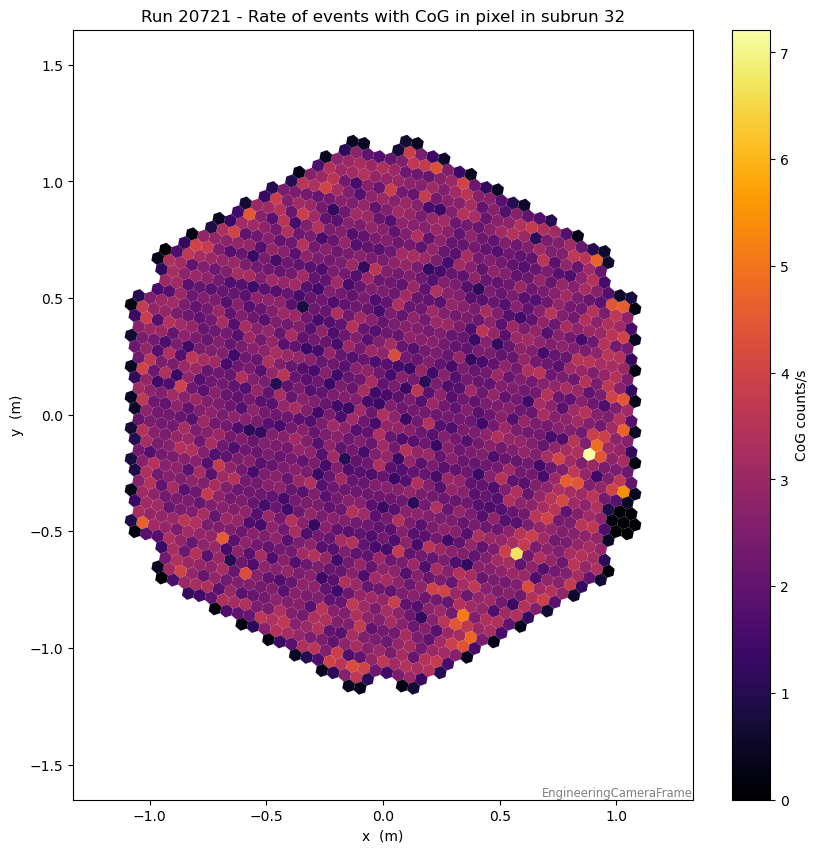

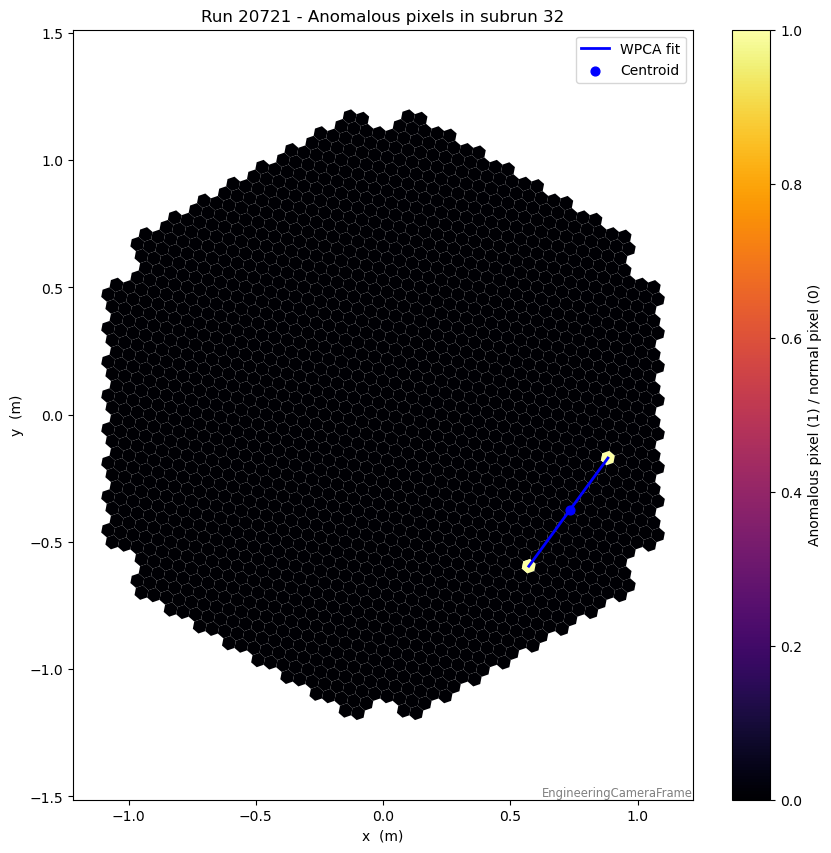

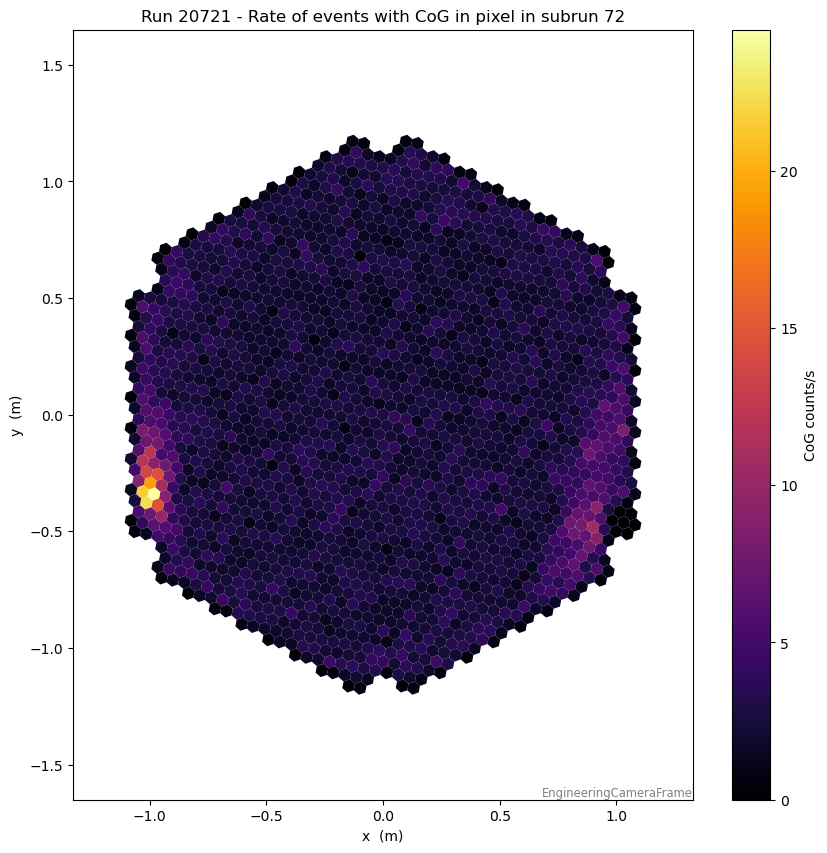

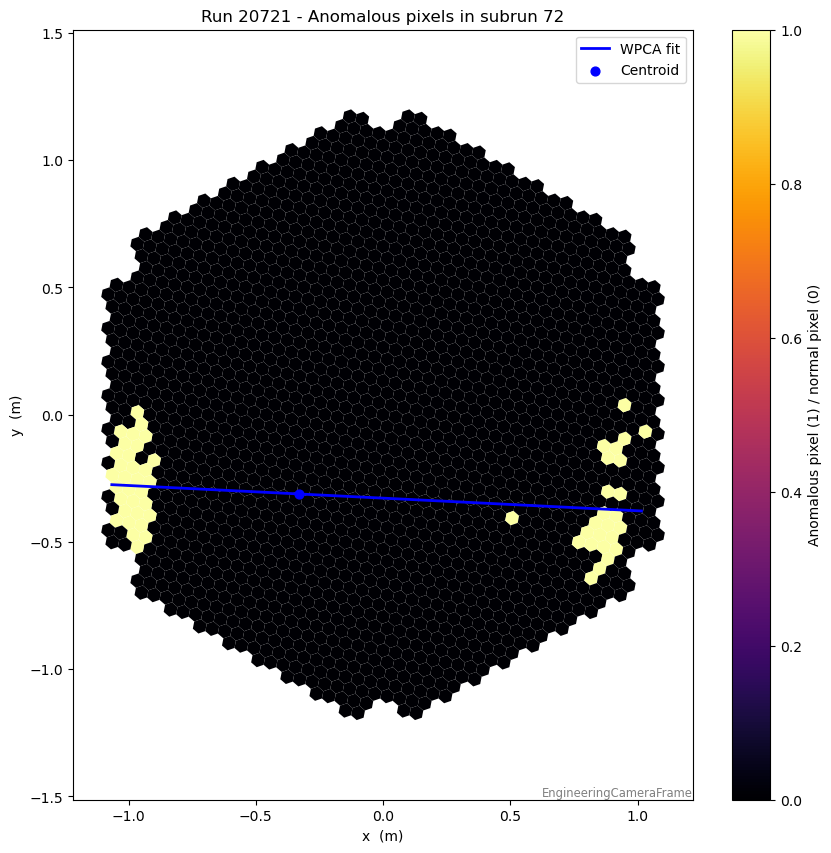

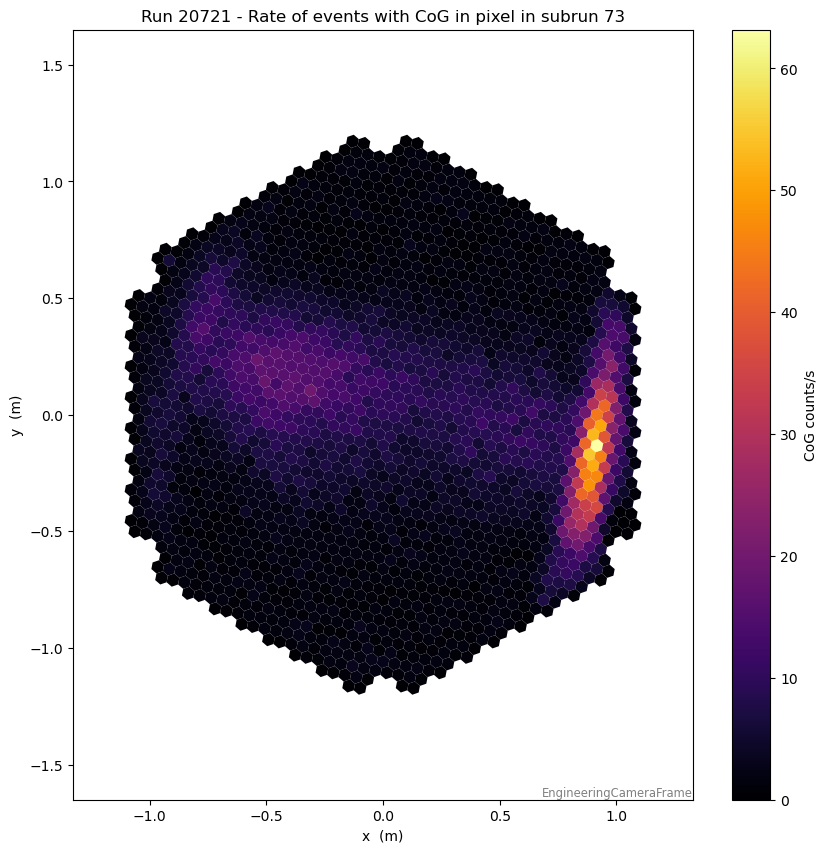

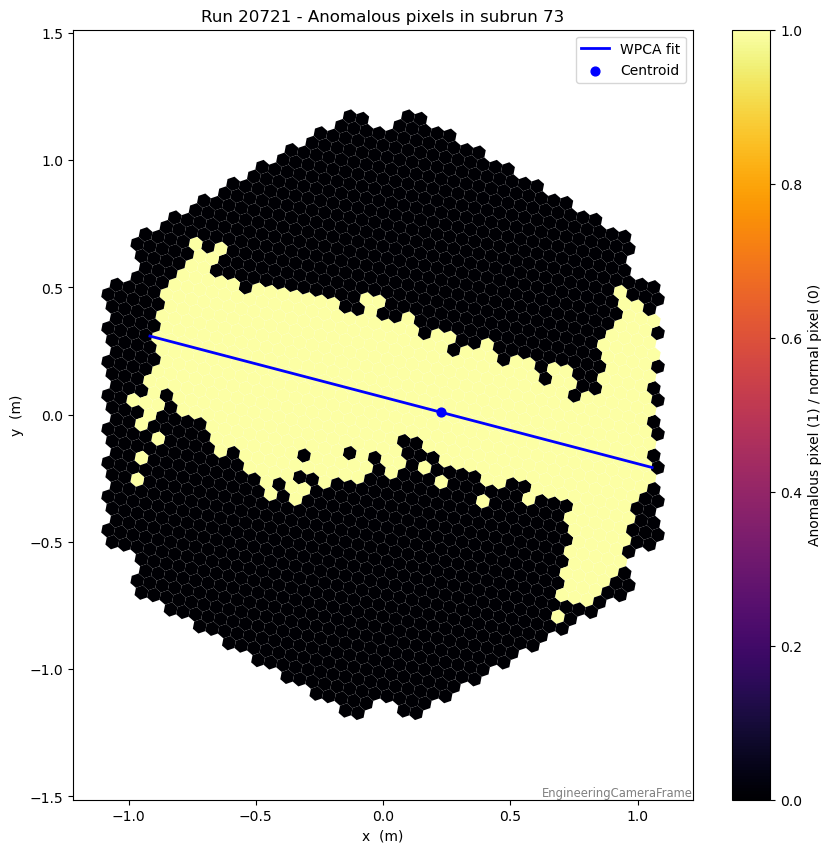

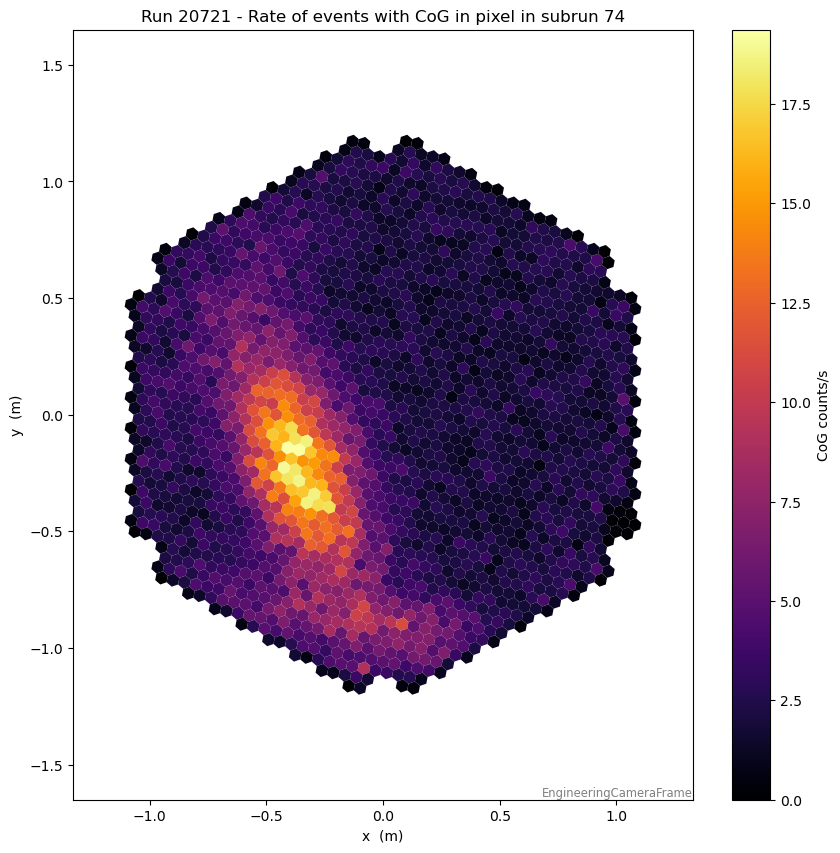

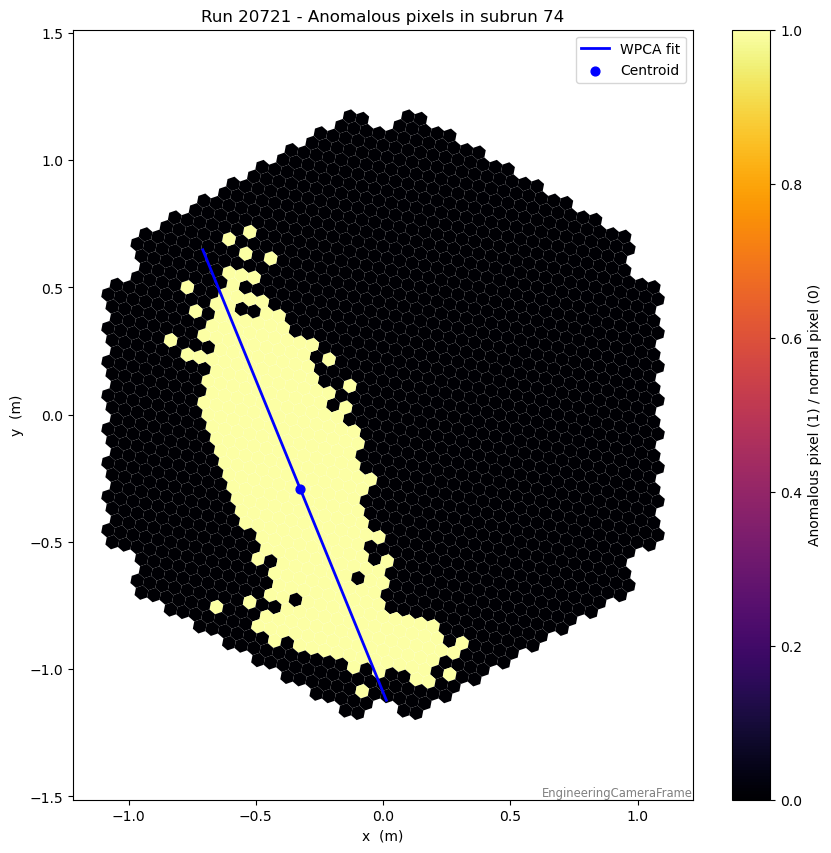

Run id:  [20721]
Chi2 data:  [np.float64(2.1289888853118687e-30), np.float64(35.04028837843363), np.float64(74.44224165360902), np.float64(31.076238759183433)]


In [12]:
# FILTER 3: FLUCTUATIONS OF CoG WITHIN PIXEL
for run_id in run_id_list: 
    b = tables.open_file(r"/data/cta/users-ifae/summer_students/agl/1500_checks_h5/checks_Run{run_id}.h5".format(run_id= run_id))
    a = tables.open_file(r"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5".format(run_id= run_id))
    
    cog_pixel = a.root.dl1datacheck.cosmics.col('cog_within_pixel')[:-1]  # shape: (n_subruns, n_pixels)
    time = a.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]
    subruns =  a.root.dl1datacheck.cosmics.col('subrun_index')[:-1]
    cog_rate = cog_pixel / time[:, None]
    cog_sigma = np.sqrt(np.maximum(cog_pixel, 1.0)) / time[:, None] # Poisson-like uncertainty associated to each value
    
    
    # 3.1: ROBUST FIT TO SELECT PIXELS IN WHICH THE ANOMALY HAS FALLEN 
    cog_fit = robust_fitt(subruns, cog_rate)["fit"]
    
    # Selection criteria
    cog_z_score = (cog_rate - cog_fit) / cog_sigma
    mask_3 = (cog_z_score) > 3 # when taking np.abs(z_score), much more anomalous pixels appear
    
    checks =  b.root.general.cosmics.col('subrun_index') # look at the checks previously selected by toy2.py and see if they satisfy the condition for Filter 3
    
    checks_3 = []
    chis2 = []
    runs = []
    runs.append(run_id)

    for c in checks:
        if np.any(mask_3[c]):
            checks_3.append(c)


    for check in checks_3:
    # 3.2: PCA FIT OF THE SELECTED PIXELS
    # we expect bodies such as satellites (our main interest) or meteorites to cross the camera FoV in a straight trajectory
    # to check this, having identified the 'affected' pixels, we aim to do a linear fit (PCA) and determine whether the selected pixels do form a straight line via a Chi^2 test 
    
    # to do the linear fit with the selected pixels, we'll use the PCA method so that our fit does not depend on the frame and we can
    # include the cases of completely vertical or horizontal lines
    
        anomaly_image = mask_3[check].astype(int)
        
        # Plot of CoG rate within pixel for anomalous subrun
        plt.figure(figsize=(10, 10))
        camdisplay = CameraDisplay(
            camera_geom.transform_to(EngineeringCameraFrame()),
            norm='lin',
            title=f'Run {run_id} - Rate of events with CoG in pixel in subrun {check}',
            image=cog_rate[check, :],
        )
        camdisplay.autoupdate = True
        camdisplay.add_colorbar(label='CoG counts/s')
        plt.show()
        
        
        # 3.2: WEIGHTED PCA FIT OF THE SELECTED PIXELS
        # Linear fit to check that indeed the path is linear, x=-y y=-x
        
        # Positions of anomalous pixels
        x_pixels = camera_geom.transform_to(EngineeringCameraFrame()).pix_x[mask_3[check]].value  # .value to remove the units in the array, we need to transf to eng. camera frame to plot it correctly
        y_pixels = camera_geom.transform_to(EngineeringCameraFrame()).pix_y[mask_3[check]].value
        
        m_pixels = np.column_stack((x_pixels, y_pixels)) #matrix of the shape columns: pixel, rows: x_pixel, y_pixel
        
        # Weights for the x and y (are the same for each pixel), the weigh will be the normalized cog rate
        cog_rate_anomalous = cog_rate[check][mask_3[check]]  
        
        # Fit + Elements of the linear fit to draw
        centroid, direction_vector = wpca(m_pixels, cog_rate_anomalous)
        projection = (m_pixels - centroid) @ direction_vector # projection of the position of the pixels with respect to the centroid along the direction vector
        
        t = np.linspace(projection.min(), projection.max(), 100) # drawing the line along the pixels used by the fit
        x_wpca = centroid[0] + t * direction_vector[0]
        y_wpca = centroid[1] + t * direction_vector[1]
        
        # Plot of anomalous pixels in anomalous subrun + Linear fit of those pixels with WPCA
        plt.figure(figsize=(10, 10))
        camdisplay = CameraDisplay(
            camera_geom.transform_to(EngineeringCameraFrame()),
            title=f'Run {run_id} - Anomalous pixels in subrun {check}',
            image=anomaly_image,
        )
        camdisplay.add_colorbar(label='Anomalous pixel (1) / normal pixel (0)')
        
        ax = camdisplay.axes
        ax.plot(x_wpca, y_wpca, color="blue", lw=2, label="WPCA fit")
        ax.scatter(*centroid, color="blue", s=40, label="Centroid")
        ax.legend()
        plt.show()
        
        
        # X^2 TEST TO DETERMINE IF THE PIXELS REALLY FOLLOW A STRAIGHT LINE
        
        # Coordinates of the pixels relative to the centroid
        delta = m_pixels - centroid
        
        #Distances (orthogonal) from the center of the pixels to the line of the fit
        distances = np.abs(delta[:, 0] * direction_vector[1] - delta[:, 1] * direction_vector[0])
        
        # Uncertainty of pixels !! this will have to be changed !!
        sigma_pixel = (focal_length.value)*np.tan(np.radians(0.05)) # width of the pixel ~2.44 cm
        #sigma_pixel_list = np.linspace(0.01, 0.2, 20)
        
        # Chi-square
        # Chi2 Calculated
        chi2_data = np.sum( cog_rate_anomalous * (distances / sigma_pixel)**2 ) / np.sum(cog_rate_anomalous)
        chis2.append(chi2_data)
        #for sigma_pixel in sigma_pixel_list:
         #   chi2_data = np.sum( cog_rate_anomalous * (distances / sigma_pixel)**2 ) / np.sum(cog_rate_anomalous)
          #  plt.axvline(chi2_data, color="black", linestyle='--', label=fr"$\chi^2={chi2_data:.2f}$ Data")
    print("Run id: ", runs)
    print("Chi2 data: ", chis2)

    a.close()
    b.close()
